<a href="https://colab.research.google.com/github/sarathdotgithub/Data-Science/blob/main/regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/martatolos/eae-dsaa/blob/main/regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regression

> Goal of the session:
>
> - At the end of this activity, you will understand the basics of linear and logistic regression, learn how to properly evaluate models, and practice the full ML workflow: explore, prepare, train, evaluate, interpret.
>
> Scope of the session
>
> - Walk through the basic concepts of data exploration and analysis.
> - Prepare data for machine learning (encoding, scaling).
> - Train linear and logistic regression models using `sklearn`.
> - Evaluate model performance using R², MAE, accuracy, and confusion matrices.
> - Interpret model predictions and feature importance.

## 1. Setup

### Dependencies

- ``matplotlib``
- ``numpy`` 2.4.4
- ``pandas`` 3.0.2
- ``plotly`` 5.24.1
- ``scikit-learn`` 1.8.0
- ``seaborn`` 0.13.2

> [!Note]
> Jupyter notebooks allow to install packages using ``%pip`` magic command, which is equivalent to using the ``pip`` command in the terminal.

In [1]:
%pip install numpy==2.4.4 pandas==3.0.2 plotly==5.24.1 scikit-learn==1.8.0 seaborn==0.13.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 58.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas

### Imports

After installing them, we import the libraries which we will use in this notebook. We also set the random seed to ensure reproducibility of results.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    mean_absolute_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

### Data

We will use the **carseats** dataset. This dataset contains information about sales of child car seats at 400 different stores. The goal is to predict the sales of car seats based on various features such as price, location, and other attributes.

In [2]:
car_seats = pd.read_csv(
    "https://raw.githubusercontent.com/intro-stat-learning/ISLP/refs/heads/main/ISLP/data/Carseats.csv"
)

## 2. Exploratory Data Analysis

We'll use Plotly for charts where interaction helps you explore the data (hover, zoom) and seaborn for statistical plots like pairplots and heatmaps where a static view is clearer.

In [3]:
car_seats

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes


The **carseats** dataset we loaded is a dataframe with 400 observations on the following 11 variables:

- **Sales**
Unit sales (in thousands) at each location

- **CompPrice**
Price charged by competitor at each location

- **Income**
Community income level (in thousands of dollars)

- **Advertising**
Local advertising budget for company at each location (in thousands of dollars)

- **Population**
Population size in region (in thousands)

- **Price**
Price company charges for car seats at each site

- **ShelveLoc**
A factor with levels Bad, Good and Medium indicating the quality of the shelving location for the car seats at each site

- **Age**
Average age of the local population

- **Education**
Education level at each location

- **Urban**
A factor with levels No and Yes to indicate whether the store is in an urban or rural location

- **US**
A factor with levels No and Yes to indicate whether the store is in the US or not

In [ ]:
car_seats.dtypes

**Before continuing:** What is a float? What does 64 mean? What is a category dtype?

<details>
  <summary>💡 Show answer</summary>
  <ul>
    <li>A float is a number with decimal precision (e.g. 7.99)</li>
    <li>64 refers to 64-bit precision — the number uses 8 bytes of memory</li>
    <li>A category is a column with a fixed set of possible values (e.g. "Yes"/"No")</li>
  </ul>
</details>

In [4]:
car_seats.describe()

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,7.496325,124.975000,68.657500,6.635000,264.840000,115.795000,53.322500,13.900000
std,2.824115,15.334512,27.986037,6.650364,147.376436,23.676664,16.200297,2.620528
min,0.000000,77.000000,21.000000,0.000000,10.000000,24.000000,25.000000,10.000000
25%,5.390000,115.000000,42.750000,0.000000,139.000000,100.000000,39.750000,12.000000
50%,7.490000,125.000000,69.000000,5.000000,272.000000,117.000000,54.500000,14.000000
75%,9.320000,135.000000,91.000000,12.000000,398.500000,131.000000,66.000000,16.000000
max,16.270000,175.000000,120.000000,29.000000,509.000000,191.000000,80.000000,18.000000


To which conclusions can we come by analyzing above table? Should we care about the value ranges? What's missing in this table?

In [5]:
# Convert object columns to category dtype
car_seats["ShelveLoc"] = car_seats["ShelveLoc"].astype("category")
car_seats["Urban"] = car_seats["Urban"].astype("category")
car_seats["US"] = car_seats["US"].astype("category")

car_seats.describe(include=["category"])

,ShelveLoc,Urban,US
count,400,400,400
unique,3,2,2
top,Medium,Yes,Yes
freq,219,282,258


#### The convenience of proper types

Often string values of categorical variables are not recognized as such and get the ``object`` type assigned. This can lead to problems when we want to use these variables in our analysis. We can convert them to categorical variables using the ``astype`` method. This will allow us to use them better in our analysis and also save memory.

When a string column is converted from object to string, the actual values are encoded as integers and the mapping is stored in the column's metadata. This allows for more efficient storage and faster operations on the column, as the underlying data is now represented as integers rather than strings. The original string values can still be accessed using the mapping, so we don't lose any information in the process.

### Pairplot and correlation matrix

In [6]:
fig = px.scatter(car_seats, x="Price", y="Sales", color="ShelveLoc",
                 title="Sales vs Price by Shelf Location")
fig.show()

What can you see in this chart? Hover over points to inspect individual stores. Does the relationship between Price and Sales look linear?

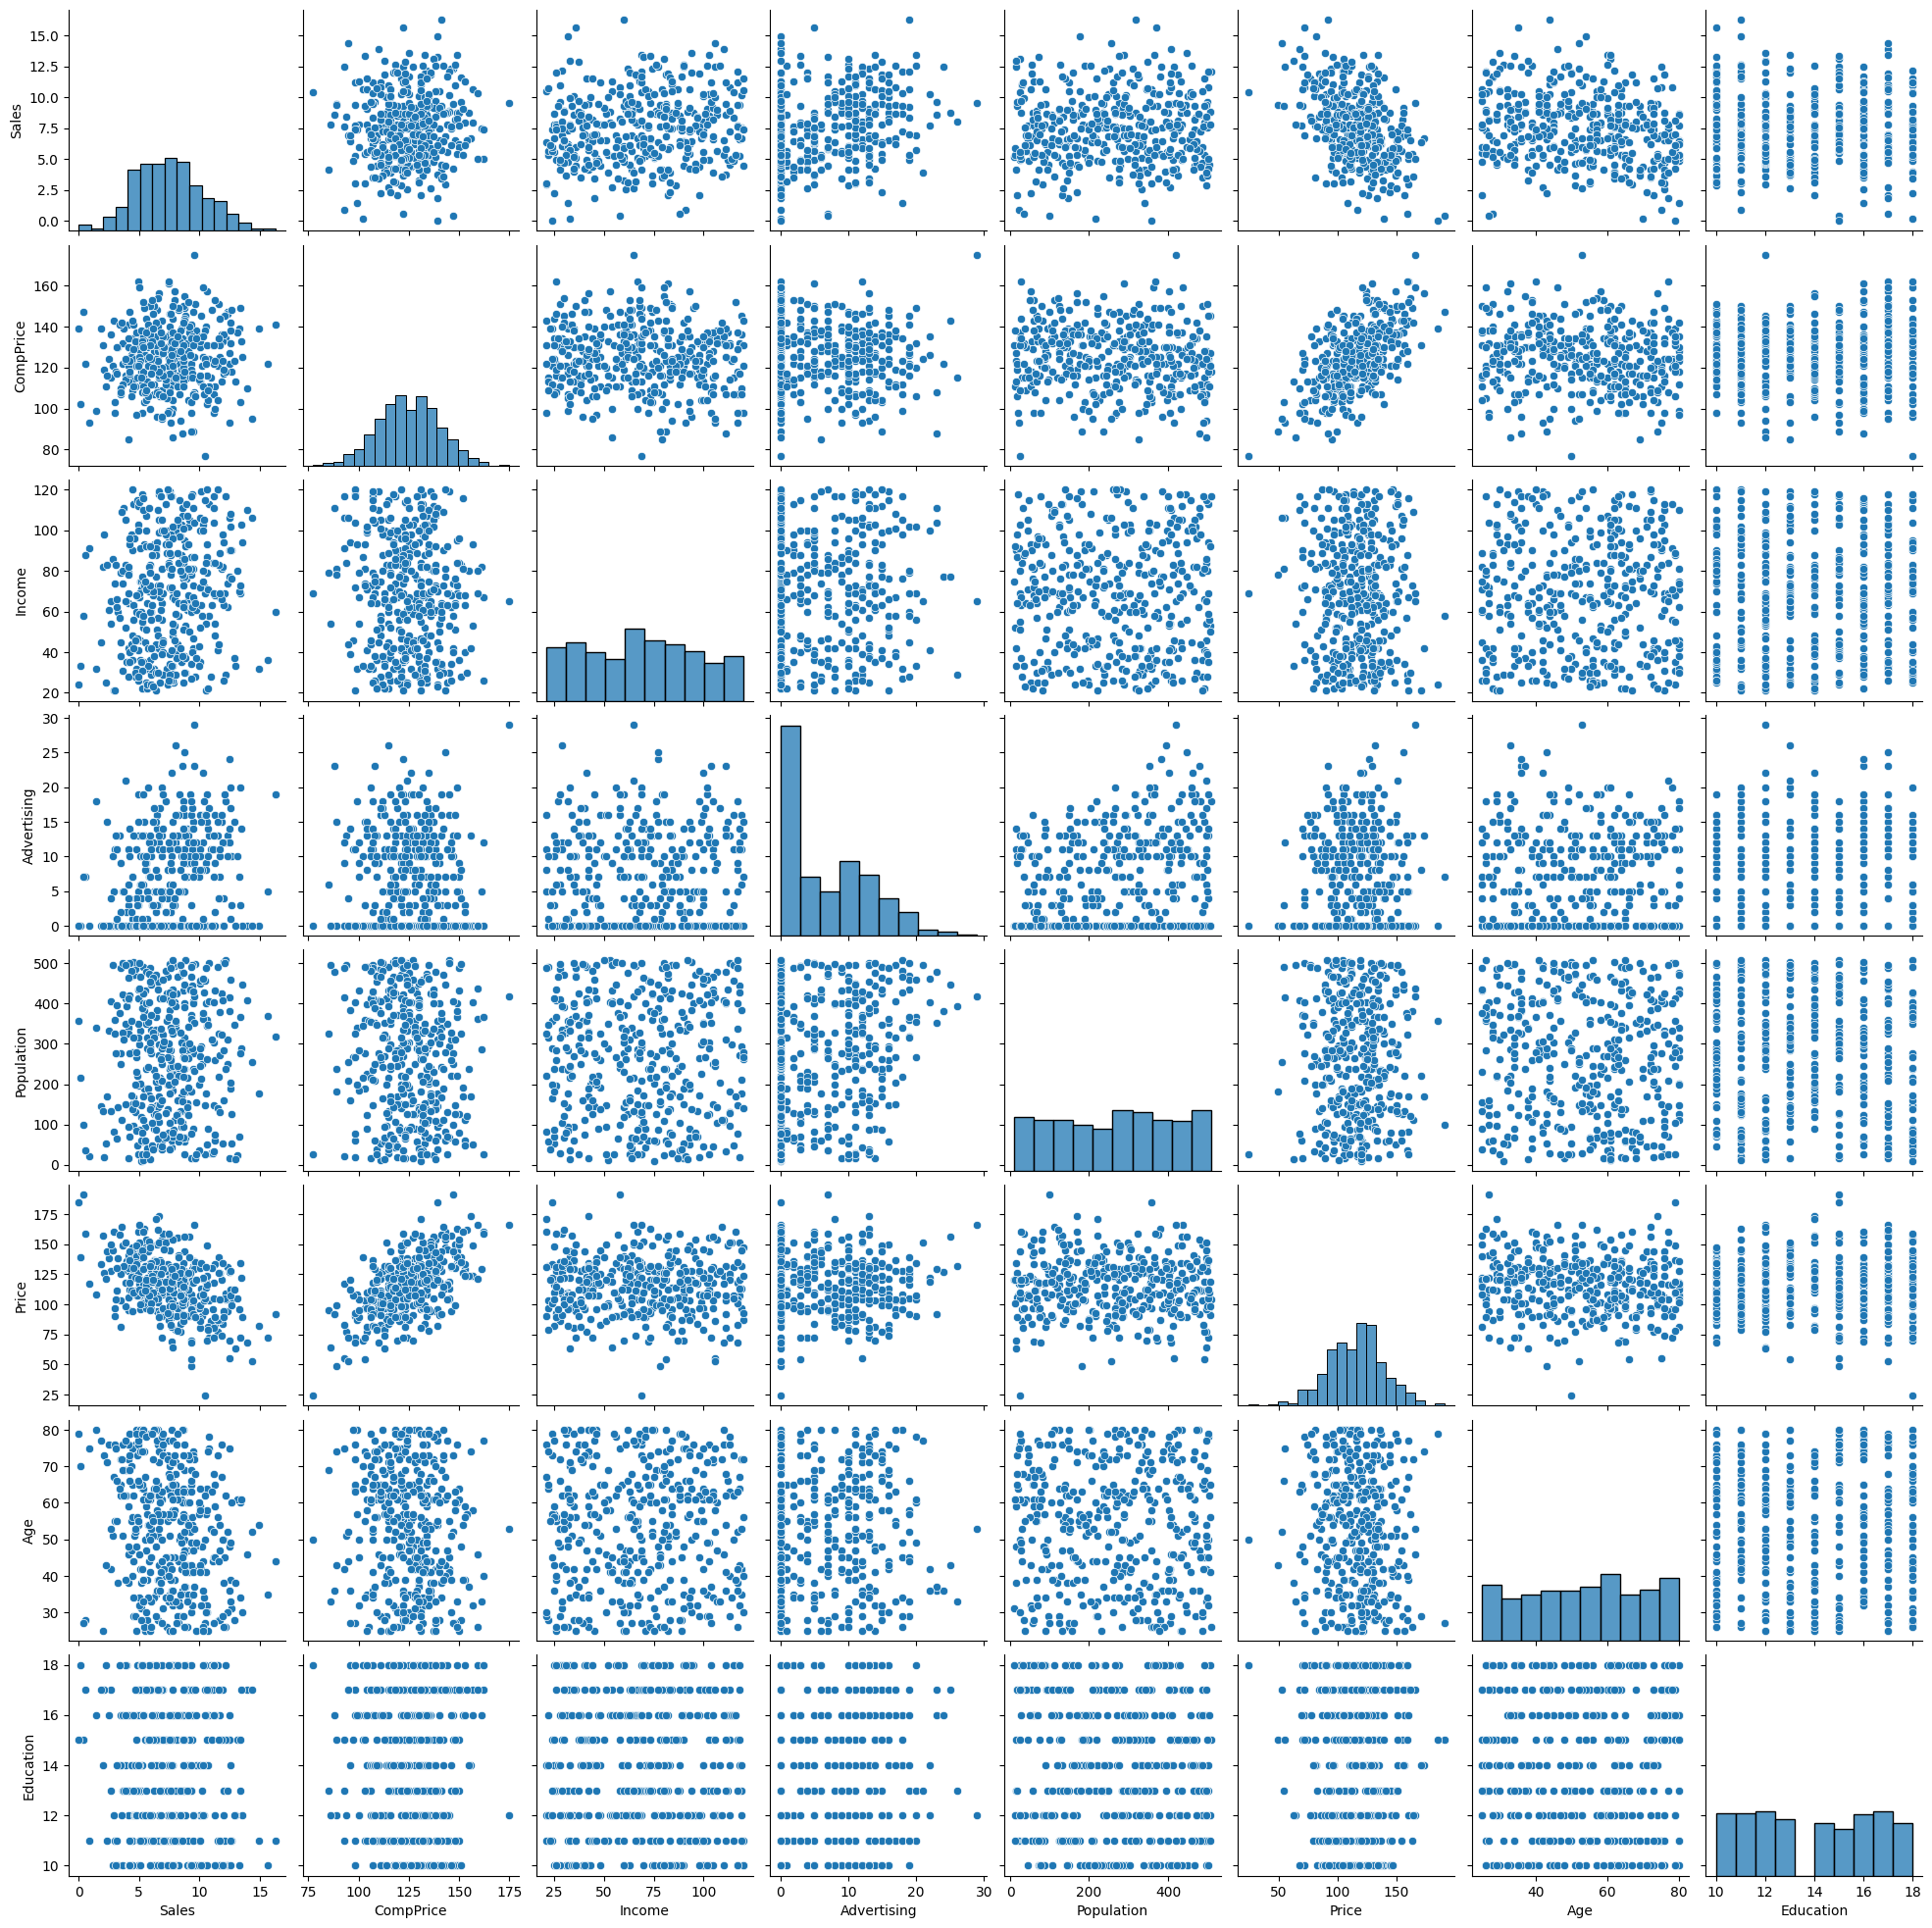

In [8]:
sns.pairplot(car_seats)  # hue="ShelveLoc"

What can we derive from the above diagram?

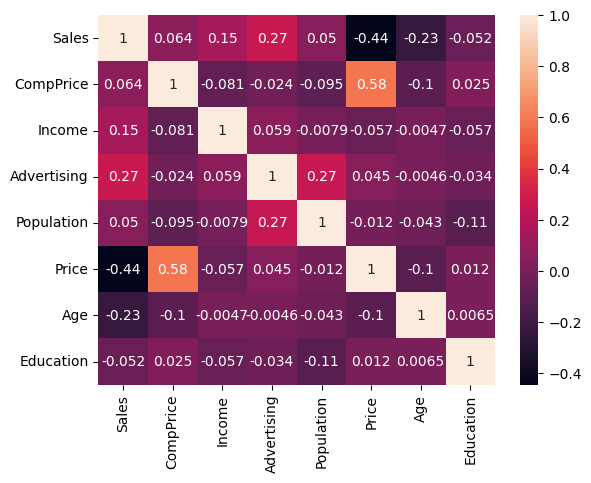

In [9]:
correlation = car_seats.corr(numeric_only=True)
sns.heatmap(correlation, annot=True)
plt.show()

Heatmaps are a quick way to spot correlations between variables.

## 3. Preparation

Can a (linear) regression algorithm work with categorical features?

In [10]:
enc = OneHotEncoder(handle_unknown="ignore")
enc.fit(car_seats[["ShelveLoc"]])
shelve_loc_ohe = enc.transform(car_seats[["ShelveLoc"]])
shelve_loc_ohe.toarray()

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       ...,
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]], shape=(400, 3))

In [11]:
list(enc.categories_[0])

['Bad', 'Good', 'Medium']

In [12]:
column_names = ["ShelveLoc" + category for category in list(enc.categories_[0])]
shelve_loc = pd.DataFrame(shelve_loc_ohe.toarray(), columns=column_names)
pd.concat([car_seats, shelve_loc], axis=1)

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,ShelveLocBad,ShelveLocGood,ShelveLocMedium
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes,1.0,0.0,0.0
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes,0.0,1.0,0.0
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes,0.0,0.0,1.0
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes,0.0,0.0,1.0
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes,0.0,1.0,0.0
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes,0.0,0.0,1.0
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes,0.0,0.0,1.0
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes,1.0,0.0,0.0


What's the difference between nominal and ordinal categorical features?

<details>
  <summary>💡 When to use one-hot vs ordinal encoding?</summary>
  <ul>
    <li>One-hot: when categories have no natural order (e.g. colors: red, blue, green)</li>
    <li>Ordinal: when categories have a meaningful order (e.g. quality: Bad &lt; Medium &lt; Good)</li>
    <li>Rule of thumb: if the order matters to the prediction, use ordinal. If not, use one-hot.</li>
  </ul>
</details>

In [14]:
car_seats["UrbanEnc"] = (car_seats["Urban"] == "Yes").astype(bool)
car_seats["USEnc"] = (car_seats["US"] == "Yes").astype(bool)

For `ShelveLoc` we use ordinal encoding because the categories have a natural order: Bad < Medium < Good.

In [15]:
car_seats["ShelveLocEnc"] = car_seats["ShelveLoc"].map({"Bad": 1, "Medium": 2, "Good": 3}).astype(int)

Now that our features are encoded as numbers, the data is ready for a machine learning model.

## 4. Linear Regression

Linear regression is a statistical method that models the relationship between a dependent variable and one or more independent variables by fitting a linear equation to observed data.

In [18]:
X = car_seats[["Income", "Advertising", "Price", "Age", "CompPrice", "ShelveLocEnc"]]
y = car_seats["Sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Training set: {len(X_train)} samples / Test set: {len(X_test)} samples")

Training set: 300 samples / Test set: 100 samples


In [19]:
reg = LinearRegression().fit(X_train, y_train)

In [20]:
y_pred = reg.predict(X_test)

print(f"R² score: {r2_score(y_test, y_pred):.3f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.3f}")

R² score: 0.875
Mean Absolute Error: 0.887


In [21]:
residuals_df = pd.DataFrame({"Predicted": y_pred, "Residuals": y_test.values - y_pred})
fig = px.scatter(residuals_df, x="Predicted", y="Residuals", title="Residual Plot")
fig.add_hline(y=0, line_dash="dash", line_color="red")
fig.show()

<details>
  <summary>💡 How to interpret the residual plot?</summary>
  <ul>
    <li>Points should be randomly scattered around the horizontal line at y=0</li>
    <li>If you see a pattern (e.g. a curve), the linear model may not capture the relationship well</li>
    <li>A good residual plot looks like random noise — no trends, no fans</li>
  </ul>
</details>

In [22]:
coefficients = reg.coef_
intercept = reg.intercept_

coef_df = pd.DataFrame({"Feature": X_train.columns, "Coefficient": coefficients})
coef_df = coef_df.sort_values("Coefficient", key=np.abs, ascending=False)
fig = px.bar(coef_df, x="Feature", y="Coefficient", title="Feature Coefficients")
fig.show()

**Exercise:** Looking at this chart, which feature has the strongest influence on Sales? Is the direction (positive/negative) what you would expect from a business perspective?

<details>
  <summary>💡 How to read this chart?</summary>
  <ul>
    <li>Positive coefficient: as the feature increases, sales tend to increase</li>
    <li>Negative coefficient: as the feature increases, sales tend to decrease</li>
    <li>Larger absolute value = stronger influence on the prediction</li>
    <li>Note: coefficients are only directly comparable when features are on the same scale. Since our features have different ranges (e.g. Income in thousands vs Age 20-80), the raw coefficient size can be misleading. We'll address this with feature scaling below.</li>
  </ul>
</details>

In [25]:
# Micro-example: manual prediction with 2 features
example_coefs = np.array([0.5, -0.3])
example_features = np.array([100, 50])
example_intercept = 5.0
manual_prediction = np.dot(example_features, example_coefs) + example_intercept
print(f"0.5 * 100 + (-0.3) * 50 + 5.0 = {manual_prediction}")

0.5 * 100 + (-0.3) * 50 + 5.0 = 40.0


Now implement the same logic for our full model. The function receives the feature values as a dictionary, the model coefficients, and the intercept:

In [26]:
def predict_sales(data: dict[str, list[float]], coefficients: np.ndarray, intercept: np.float64) -> float:
    """Generate a prediction of sales based on the coefficients and intercept of a linear regression model.

    :param data: A dictionary containing the input features for the prediction.
    :param coefficients: The coefficients of the linear regression model.
    :param intercept: The intercept of the linear regression model.
    """
    # Add your code here

<details>
  <summary>💡 Hint 1: What do you have?</summary>
  <p>Look at the variables: <code>data</code> contains your feature values, <code>coefficients</code> contains one number per feature, <code>intercept</code> is a single number. What operation combines them? (Look at the micro-example above)</p>
</details>

<details>
  <summary>💡 Hint 2: How to implement it?</summary>
  <p>Use <code>np.dot</code> to multiply two arrays element-wise and sum the results. Then add the intercept. Make sure the feature values are in the same order as the columns used to train the model.</p>
</details>

<details>
  <summary>💡 Show solution</summary>
  <pre>
  feature_cols = ["Income", "Advertising", "Price", "Age", "CompPrice", "ShelveLocEnc"]
  raw = np.array([data[col][0] for col in feature_cols])
  return float(np.dot(raw, coefficients) + intercept)
  </pre>
</details>

In [27]:
data = {"Income": [10], "Advertising": [20], "Price": [100], "Age": [20], "CompPrice": [100], "ShelveLocEnc": [3]}
X_new = pd.DataFrame(data)

predicted_sales = predict_sales(data, coefficients, intercept)
model_sales = reg.predict(X_new)[0]

print(f"Predicted sales: {predicted_sales}")
print(f"Model sales: {model_sales}")

if predicted_sales is None:
    print("predict_sales is not implemented yet — add your code to the function above.")
elif round(predicted_sales, 3) == round(model_sales, 3):
    print("The predicted sales match the model's prediction.")
else:
    print("The predicted sales do not match the model's prediction.")

Predicted sales: None
Model sales: 11.491788374099757
predict_sales is not implemented yet — add your code to the function above.


### Preview: Feature Scaling and Pipelines

Some machine learning algorithms (like SVMs, which you'll see in a later lab) are sensitive to feature scales. Linear regression is not, but let's see what scaling does — it also makes coefficients directly comparable.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_price = scaler.fit_transform(X_train[["Price"]])
print(f"Original — mean: {X_train['Price'].mean():.1f}, std: {X_train['Price'].std():.1f}")
print(f"Scaled   — mean: {scaled_price.mean():.4f}, std: {scaled_price.std():.4f}")

In [ ]:
pipe = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
pipe.fit(X_train, y_train)
print(f"Pipeline R² on test set: {pipe.score(X_test, y_test):.3f}")

## 5. Logistic Regression

Logistic regression is a statistical method used for binary classification problems - predicting outcomes with two possible values (e.g., yes/no, 0/1, true/false).

Unlike linear regression which predicts continuous values, logistic regression predicts the probability that an instance belongs to a particular class.

### The Logistic Function

Logistic regression uses the sigmoid function (also called the logistic function) to transform its output to a probability between 0 and 1:

$P(y=1|x) = \frac{1}{1 + e^{-z}}$

Where $z = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n$ (the linear combination of features)

![Sigmoid function](https://upload.wikimedia.org/wikipedia/commons/thumb/8/88/Logistic-curve.svg/320px-Logistic-curve.svg.png)

### How Logistic Regression Works:

1. **Model Formula**: $\log(\frac{p}{1-p}) = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n$
    - $p$ is the probability of the positive class
    - $\frac{p}{1-p}$ is the odds ratio
    - $\log(\frac{p}{1-p})$ is the log odds or "logit"

2. **Decision Boundary**: When probability > 0.5, we predict class 1; otherwise, we predict class 0

3. **Training**: Uses maximum likelihood estimation to find the best parameters

### Key Differences from Linear Regression:

- Predicts probabilities instead of continuous values
- Output is bounded between 0 and 1
- Uses log loss (cross-entropy) instead of mean squared error
- Decision boundary is non-linear in input space but linear in feature space

> **Note:** We include `Sales` as a feature here because it is a measured attribute of each store. In a real-world project, think carefully about whether a feature could be derived from or influenced by the target variable — using such features is called **data leakage** and can make a model appear better than it actually is.

In [ ]:
X = car_seats[["Income", "Advertising", "Price", "Age", "CompPrice", "ShelveLocEnc", "Sales"]]
y = car_seats["USEnc"]

print(y.value_counts())

Before training, check whether the classes are balanced. If one class is much more common, accuracy alone can be misleading.

In this example, we will use logistic regression to predict whether a store is in the US or not based on other features. The model will output a probability, and we will classify it as "US" if the probability is greater than 0.5.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
log_reg = LogisticRegression(max_iter=1000).fit(X_train, y_train)

In [ ]:
y_pred = log_reg.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred, target_names=["Non-US", "US"]))

In [ ]:
ConfusionMatrixDisplay.from_estimator(log_reg, X_test, y_test, display_labels=["Non-US", "US"])
plt.show()

**Exercise:** Which cells in the matrix represent correct predictions? Which represent errors?

<details>
  <summary>💡 How to read a confusion matrix?</summary>
  <ul>
    <li>Diagonal (top-left, bottom-right): correctly classified samples</li>
    <li>Off-diagonal: misclassified samples</li>
    <li>Top-right (False Positive): predicted US but was Non-US</li>
    <li>Bottom-left (False Negative): predicted Non-US but was US</li>
  </ul>
</details>

In [ ]:
probabilities = log_reg.predict_proba(X_test)[:5]
print("First 5 predictions — [P(Non-US), P(US)]:")
print(probabilities)

### Quick Reference: Which Model to Use?

| Target variable type | Model | Example |
|---------------------|-------|---------|
| Continuous (numbers) | Linear Regression | Predict Sales (0.0 to 16.0) |
| Binary (yes/no) | Logistic Regression | Predict US store (True/False) |

## 6. Capstone Exercise

Using what you've learned in this lab:

1. Choose a **different target variable** from the Carseats dataset (e.g., predict `CompPrice` with linear regression, or predict `Urban` with logistic regression)
2. Prepare the features (select relevant columns — remember to exclude your target!)
3. Split into train/test sets
4. Train the appropriate model (linear or logistic regression)
5. Evaluate performance using the metrics we've covered
6. Look at the top 3 features by coefficient size. For each one, write one sentence explaining whether the direction (positive/negative) makes sense from a business perspective.

<details>
  <summary>💡 Need help getting started?</summary>
  <ul>
    <li>For predicting CompPrice → use LinearRegression (continuous target). Evaluate with R² and MAE.</li>
    <li>For predicting Urban → use LogisticRegression (binary target). Urban is already encoded as UrbanEnc (True/False). Evaluate with accuracy and confusion matrix.</li>
    <li>Don't forget to create your train/test split before training!</li>
  </ul>
</details>